In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


buat ngecek foldernya ada atau enggak

In [ ]:
import os

# Mencari file trainingSet.tar.gz di seluruh Google Drive yang terhubung
file_dicari = "trainingSet.tar.gz"
lokasi_ketemu = []

for root, dirs, files in os.walk('/content/drive/MyDrive/dataset_handwriting'):
    if file_dicari in files:
        lokasi_ketemu.append(os.path.join(root, file_dicari))

if lokasi_ketemu:
    print("File ketemu di sini:")
    for loc in lokasi_ketemu:
        print(loc)
else:
    print("File nggak ketemu! Pastiin lu udah 'Add Shortcut' ke MyDrive.")

File ketemu di sini:
/content/drive/MyDrive/dataset_handwriting/trainingSet.tar.gz


In [ ]:
import os
import shutil

# 1. Pathnya udah gw update sesuai lokasi asli file lu!
path_di_drive = '/content/drive/MyDrive/dataset_handwriting/trainingSet.tar.gz'

# 2. Ekstrak ke lokal Colab
print("Sedang mengekstrak file dari Drive...")
!tar -xzf "{path_di_drive}" -C /content/

# 3. Setup folder untuk format YOLO
source_dir = '/content/trainingSet'
output_dir = '/content/yolo_mnist_dataset'

os.makedirs(f'{output_dir}/images/train', exist_ok=True)
os.makedirs(f'{output_dir}/labels/train', exist_ok=True)

print("Memulai konversi ke format YOLO (tunggu bentar ya)...")

# 4. Generate file .txt YOLO
for label_class in range(10):
    class_dir = os.path.join(source_dir, str(label_class))
    if not os.path.exists(class_dir):
        continue

    for img_name in os.listdir(class_dir):
        if img_name.endswith('.jpg'):
            # Copy gambar
            src_img_path = os.path.join(class_dir, img_name)
            dst_img_path = os.path.join(output_dir, 'images', 'train', img_name)
            shutil.copy(src_img_path, dst_img_path)

            # Bikin label YOLO
            txt_name = img_name.replace('.jpg', '.txt')
            txt_path = os.path.join(output_dir, 'labels', 'train', txt_name)
            with open(txt_path, 'w') as f:
                f.write(f"{label_class} 0.5 0.5 1.0 1.0\n")

# 5. Bikin file konfigurasi data.yaml
yaml_content = f"""
train: {output_dir}/images/train
val: {output_dir}/images/train

nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
"""

with open(f'{output_dir}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("Konversi Beres! Gambar lu udah masuk ke folder yang bener.")

Sedang mengekstrak file dari Drive...
Memulai konversi ke format YOLO (tunggu bentar ya)...
Konversi Beres! Gambar lu udah masuk ke folder yang bener.


In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Pake YOLOv8 dulu, YOLOv12 gabisa gatau napa
model = YOLO('yolov8n.pt')

# Training dimulai
results = model.train(
    data='/content/yolo_mnist_dataset/data.yaml',
    epochs=2,
    imgsz=32,
    device=0,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_mnist_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.

oiya kalau kau liat eror di cell atas ni, itu gara2 ku stop paksa. tapi udah bisa kok dipake buat tes baca tulisannya (pake cell dibawah). oiya ini baru cuman bisa deteksi 1 ANGKA PER IMAGE. - 81

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Sedang memproses gambar dengan Auto-Crop Magic...
Auto-Crop Berhasil! Gambar udah di-crop mepet dan dibuat presisi.

HASIL DETEKSI YOLO (SETELAH AUTO-CROP):
KETEMU! Ini adalah angka : [ 1 ]
Tingkat keyakinan model  : 97.69%



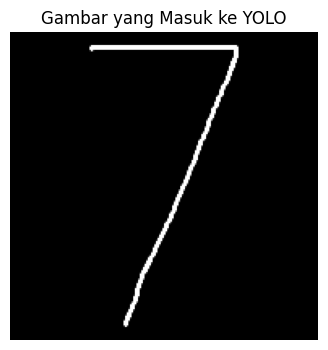

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Pastikan model dan gambar lu ada
model_path = '/content/drive/MyDrive/dataset_handwriting/ModelMalwareLegitHengker2025.pt'
path_foto = '/content/seben.png'

if not os.path.exists(model_path):
    print(f"Waduh, model nggak ketemu di: {model_path}")
elif not os.path.exists(path_foto):
    print(f"Foto '{path_foto}' nggak ketemu! Pastiin udah di-upload.")
else:
    trained_model = YOLO(model_path)
    print("Sedang memproses gambar dengan Auto-Crop Magic...")

    # --- AUTO-CROP & SQUARE MAGIC ---
    img = cv2.imread(path_foto)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Invert warna kalau background putih (biar angka jadi putih, background hitam)
    if np.mean(gray) > 127:
        gray = cv2.bitwise_not(gray)
        img = cv2.bitwise_not(img)

    # 2. Thresholding biar garisnya solid
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    # 3. Cari kontur (tepian) dari angka lu
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Cari bounding box (kotak) yang paling luar dari seluruh kontur angka
        x_min, y_min = img.shape[1], img.shape[0]
        x_max, y_max = 0, 0

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            x_min = min(x_min, x)
            y_min = min(y_min, y)
            x_max = max(x_max, x + w)
            y_max = max(y_max, y + h)

        # Kasih padding (jarak aman pinggiran) misal 8 pixel biar nggak potong garis
        pad = 8
        x_min = max(0, x_min - pad)
        y_min = max(0, y_min - pad)
        x_max = min(img.shape[1], x_max + pad)
        y_max = min(img.shape[0], y_max + pad)

        # Crop gambarnya jadi mepet
        img_cropped = img[y_min:y_max, x_min:x_max]

        # 4. Bikin gambarnya jadi Kotak (Square) biar YOLO nggak bikin angkanya gepeng
        h_c, w_c = img_cropped.shape[:2]
        size = max(h_c, w_c) # Ambil sisi terpanjang

        # Bikin kanvas hitam baru bentuk persegi
        square_img = np.zeros((size, size, 3), dtype=np.uint8)

        # Taruh angka yang udah di-crop tepat di tengah-tengah kanvas
        y_offset = (size - h_c) // 2
        x_offset = (size - w_c) // 2
        square_img[y_offset:y_offset+h_c, x_offset:x_offset+w_c] = img_cropped

        # Simpan sementara untuk dites
        path_tes = '/content/angka_autocrop.png'
        cv2.imwrite(path_tes, square_img)
        print("Auto-Crop Berhasil! Gambar udah di-crop mepet dan dibuat presisi.\n")

        # --- PREDIKSI ---
        results = trained_model.predict(source=path_tes, save=False, verbose=False, conf=0.15)
        kotak_deteksi = results[0].boxes

        print("="*40)
        print("HASIL DETEKSI YOLO (SETELAH AUTO-CROP):")
        print("="*40)

        if len(kotak_deteksi) == 0:
            print("WADUH: Model masih ragu. Ketebalan garis mungkin ngaruh banget.")
        else:
            for box in kotak_deteksi:
                id_kelas = int(box.cls[0].item())
                nama_kelas = trained_model.names[id_kelas]
                akurasi = round(box.conf[0].item() * 100, 2)

                print(f"KETEMU! Ini adalah angka : [ {nama_kelas} ]")
                print(f"Tingkat keyakinan model  : {akurasi}%")
        print("="*40 + "\n")

        # Tampilin gambarnya biar lu bisa liat perbandingan potongannya
        plt.figure(figsize=(4,4))
        plt.title("Gambar yang Masuk ke YOLO")
        plt.imshow(cv2.cvtColor(square_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

    else:
        print("Gagal: Nggak nemu goresan angka apa-apa di gambar ini.")